In [1]:
import torch
from torch.utils.data import Dataset 
from torch.utils.data import DataLoader
from torchvision import transforms
import torch.nn as nn
import torchvision.models as models
from torchvision import datasets, transforms
from pathlib import Path
import numpy as np
from torch.utils.data import DataLoader, random_split
from collections import Counter
import json
from collections import defaultdict
from tqdm import tqdm
from PIL import Image
import matplotlib.pyplot as plt
import os
print(torch.__version__)
print("Done")

2.6.0+cu124
Done


In [2]:
if torch.cuda.is_available():
    device = "cuda"
    datatype = torch.float16
else:
    device = "cpu"
    datatype = torch.float32
print(f"The device is : {device} \nThe datatype is :{datatype}")

The device is : cuda 
The datatype is :torch.float16


In [3]:
base_dir = Path(r"C:\Users\Zohaib\Documents\Rehman_Personal")
images_dir = base_dir / "img_val2017" / "val2017"
annotations_dir =  base_dir / "annot_val2017" / "annotations"

In [4]:
images_list = [img for img in images_dir.iterdir()]
print(len(images_list))

5000


In [5]:
extensions = Counter(p.suffix.lower() for p in images_dir.iterdir() if p.is_file())

print("Image types in folder:")
for ext, count in extensions.items():
    print(ext, count)

Image types in folder:
.jpg 5000


In [6]:
annotation_file = annotations_dir / "captions_val2017.json"

In [7]:
with open(annotation_file, "r") as f:
    data = json.load(f)

print(type(data))

<class 'dict'>


In [8]:
print(data.keys())
print((data['images'][0]))
print(data['annotations'][0])

dict_keys(['info', 'licenses', 'images', 'annotations'])
{'license': 4, 'file_name': '000000397133.jpg', 'coco_url': 'http://images.cocodataset.org/val2017/000000397133.jpg', 'height': 427, 'width': 640, 'date_captured': '2013-11-14 17:02:52', 'flickr_url': 'http://farm7.staticflickr.com/6116/6255196340_da26cf2c9e_z.jpg', 'id': 397133}
{'image_id': 179765, 'id': 38, 'caption': 'A black Honda motorcycle parked in front of a garage.'}


In [9]:
image_id_to_name = {img["id"]: img["file_name"] for img in data["images"]}

In [10]:
image_to_captions = defaultdict(list)

for ann in data["annotations"]:
    image_id = ann["image_id"]
    caption = ann["caption"]
    
    file_name = image_id_to_name[image_id]
    image_to_captions[file_name].append(caption)

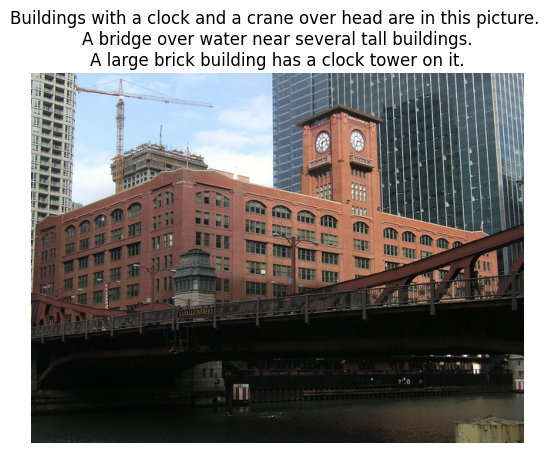

In [11]:
image_num = 508
captions=image_to_captions[(images_list[image_num].name)]
img = Image.open(images_dir / images_list[image_num].name)
plt.imshow(img)
plt.axis("off")
plt.title("\n".join(captions[:3]))  # show first 3 captions
plt.show()

In [12]:
imgpath_to_caption = {}
for img_name , captions in image_to_captions.items():
    img_path = images_dir / img_name
    imgpath_to_caption[img_path] = captions

In [13]:
print(list(imgpath_to_caption.items())[0])

(WindowsPath('C:/Users/Zohaib/Documents/Rehman_Personal/img_val2017/val2017/000000179765.jpg'), ['A black Honda motorcycle parked in front of a garage.', 'A Honda motorcycle parked in a grass driveway', 'A black Honda motorcycle with a dark burgundy seat.', 'Ma motorcycle parked on the gravel in front of a garage', 'A motorcycle with its brake extended standing outside'])


In [14]:
pairs = []

for img_path, captions in imgpath_to_caption.items():
    for cap in captions:
        pairs.append((img_path, cap))

In [15]:
pairs[2500]

(WindowsPath('C:/Users/Zohaib/Documents/Rehman_Personal/img_val2017/val2017/000000465129.jpg'),
 'A person adjusting a  metal object hanging from a ceiling.')

In [19]:
transform = transforms.Compose([
    transforms.Lambda(lambda img: img.convert("RGB")),
    transforms.Resize((224,224)),
    transforms.ToTensor()
])
class ImageDataset(Dataset):

    def __init__(self, pairs, transform=None):
        self.pairs = pairs
        self.transform = transform

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):

        img_path, _ = self.pairs[idx]

        image = Image.open(img_path)

        if self.transform:
            image = self.transform(image)

        return image

dataset = ImageDataset(pairs, transform=transform)

loader = torch.utils.data.DataLoader(
    dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0
)


In [34]:
def compute_image_mean_std(loader):
    mean = 0.
    std = 0.
    nb_samples = 0

    for images in tqdm(loader, desc="Computing mean/std"):
        batch_samples = images.size(0) 
        images = images.view(batch_samples, images.size(1), -1)  

        mean += images.mean(2).sum(0)  
        std += images.std(2).sum(0)    
        nb_samples += batch_samples

    mean /= nb_samples
    std /= nb_samples

    return mean, std
#  time to build the vocab etc as well.
def build_vocab(pairs, freq_threshold=1):
    counter = Counter()

    for _, caption in pairs:
        tokens = caption.lower().split()  # simple tokenization
        counter.update(tokens)

    vocab = {}

    # Add special tokens first
    vocab["<pad>"] = 0
    vocab["<start>"] = 1
    vocab["<end>"] = 2
    vocab["<unk>"] = 3

    idx = 4
    for word, count in counter.items():
        if count >= freq_threshold:
            vocab[word] = idx
            idx += 1

    return vocab

In [ ]:
mean , std = compute_image_mean_std(loader=loader)
print(mean , std)

Computing mean/std: 100%|██████████| 782/782 [04:26<00:00,  2.93it/s]


In [ ]:
norm_transform = transforms.Compose([
    transforms.Lambda(lambda img: img.convert("RGB")),
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean , std=std)
])
norm_dataset = ImageDataset(pairs, transform=norm_transform)

norm_loader = torch.utils.data.DataLoader(
    norm_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0
)
norm_mean , norm_std = compute_image_mean_std(loader=norm_loader)
print(norm_mean, norm_std)

In [40]:
image_transform = transforms.Compose([
    transforms.Lambda(lambda img: img.convert("RGB")),
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=norm_mean, std=norm_std)
])
vocab = build_vocab(pairs=pairs , freq_threshold=1)

In [62]:
vocab = build_vocab(pairs=pairs , freq_threshold=1)
print(len(vocab))

10011


In [42]:
class CaptionDataset(Dataset):

    def __init__(self, pairs, vocab, transform=None, max_len=30):
        self.pairs = pairs
        self.vocab = vocab
        self.transform = transform
        self.max_len = max_len

    def __len__(self):
        return len(self.pairs)

    def tokenize(self, caption):
        tokens = caption.lower().split()
        tokens = ["<start>"] + tokens + ["<end>"]

        ids = [self.vocab.get(t, self.vocab["<unk>"]) for t in tokens]

        if len(ids) < self.max_len:
            ids += [self.vocab["<pad>"]] * (self.max_len - len(ids))
        else:
            ids = ids[:self.max_len]

        return torch.tensor(ids)

    def __getitem__(self, idx):

        img_path, caption = self.pairs[idx]

        image = Image.open(img_path)

        if self.transform:
            image = self.transform(image)

        caption_ids = self.tokenize(caption)

        input_caption = caption_ids[:-1]
        target_caption = caption_ids[1:]

        return image, input_caption, target_caption

In [43]:
main_dataset = CaptionDataset(pairs=pairs , vocab=vocab , transform=image_transform)

In [127]:
def collate_function(batch, mask_token=None):
    
    image_batch = torch.stack([item[0] for item in batch], dim=0)
    input_embedding_batch = torch.stack([item[1] for item in batch], dim=0)
    output_embedding_batch = torch.stack([item[2] for item in batch], dim=0)
    mask = (input_embedding_batch != mask_token)
    
    return image_batch, input_embedding_batch, output_embedding_batch, mask


main_dataLoader = DataLoader(
    main_dataset,
    batch_size=128,
    shuffle=True,
    collate_fn=lambda batch: collate_function(batch , mask_token=vocab['<pad>']),  # <- comma added below
    num_workers=0  # safe on Windows
)

In [ ]:
main_dataset = CaptionDataset(pairs=pairs , vocab=vocab , transform=image_transform)
# Assuming you already have a Dataset object, e.g. `ImageCaptionDataset`


# Split dataset into train/val
val_ratio = 0.1  # 10% for validation
val_size = int(len(main_dataset) * val_ratio)
train_size = len(main_dataset) - val_size

train_dataset, val_dataset = random_split(main_dataset, [train_size, val_size])

# Create loaders
batch_size = 128
main_dataLoader = DataLoader(
    main_dataset,
    batch_size=128,
    shuffle=True,
    collate_fn=lambda batch: collate_function(batch , mask_token=vocab['<pad>']),  # <- comma added below
    num_workers=0  # safe on Windows
)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,collate_fn=lambda batch: collate_function(batch , mask_token=vocab['<pad>']), num_workers=0  )
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False,collate_fn=lambda batch: collate_function(batch , mask_token=vocab['<pad>']), num_workers=0 )

In [129]:
images, input_caps, target_caps, masks = next(iter(train_loader))

print(images.shape)       # (32, 3, 224, 224)
print(input_caps.shape)   # (32, max_len)
print(target_caps.shape)  # (32, max_len)
print(masks.shape)        # (32, max_len)

torch.Size([128, 3, 224, 224])
torch.Size([128, 29])
torch.Size([128, 29])
torch.Size([128, 29])


In [132]:
print(len(train_loader))
print(len(val_loader))

176
20


In [133]:
class CNNEncoder(nn.Module):
    def __init__(self, embed_size=512, train_cnn=False):
        super().__init__()
        
        resnet = models.resnet50(pretrained=True)
        
        
        modules = list(resnet.children())[:-2]  
        self.cnn = nn.Sequential(*modules)  
        
        
        self.fc = nn.Linear(2048, embed_size)
        
        self.train_cnn = train_cnn

    def forward(self, images):
        
        with torch.set_grad_enabled(self.train_cnn):
            features = self.cnn(images)  
        
        B, C, H, W = features.size()
        features = features.view(B, C, H*W).permute(0, 2, 1)  # (B, 49, 2048)
        features = self.fc(features)  # (B, 49, embed_size)
        return features  # (B, 49, 512) if embed_size=512

In [134]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=128):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-torch.log(torch.tensor(10000.0)) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)  # (1, max_len, d_model)
        self.register_buffer('pe', pe)

    def forward(self, x):
        # x: (B, seq_len, d_model)
        x = x + self.pe[:, :x.size(1), :]
        return x

In [135]:
class TransformerDecoder(nn.Module):
    def __init__(self, vocab_size, embed_size=512, num_layers=6, nhead=8, dim_feedforward=2048, max_len=128, dropout=0.1):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_size)
        self.pos_encoder = PositionalEncoding(embed_size, max_len) # gonna return the B, Seq_len , d_model=512
        
        decoder_layer = nn.TransformerDecoderLayer(
            d_model=embed_size,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout
        )
        self.transformer_decoder = nn.TransformerDecoder(decoder_layer, num_layers=num_layers)
        
        self.fc_out = nn.Linear(embed_size, vocab_size)
        self.embed_size = embed_size

    def forward(self, tgt, memory, tgt_mask=None, tgt_key_padding_mask=None):
       
        tgt_embed = self.embed(tgt) * (self.embed_size ** 0.5)  # (B, seq_len, embed_size)
        tgt_embed = self.pos_encoder(tgt_embed)  # add positional encoding
        
        # Transformer expects (seq_len, B, embed_size)
        tgt_embed = tgt_embed.permute(1, 0, 2)
        memory = memory.permute(1, 0, 2)
        
        output = self.transformer_decoder(
            tgt=tgt_embed,
            memory=memory,
            tgt_mask=tgt_mask,
            tgt_key_padding_mask=tgt_key_padding_mask
        )
        
        output = output.permute(1, 0, 2)  # (B, seq_len, embed_size)
        output = self.fc_out(output)      # (B, seq_len, vocab_size)
        return output

In [136]:
class ImageCaptioningModel(nn.Module):
    def __init__(self, vocab_size, embed_size=512):
        super().__init__()
        self.encoder = CNNEncoder(embed_size=embed_size)
        self.decoder = TransformerDecoder(vocab_size=vocab_size, embed_size=embed_size)

    def forward(self, images, captions, tgt_mask=None, tgt_key_padding_mask=None):
        features = self.encoder(images)  # (B, 49, 512)
        outputs = self.decoder(
            captions,
            memory=features,
            tgt_mask=tgt_mask,
            tgt_key_padding_mask=tgt_key_padding_mask
        )
        return outputs

In [137]:
model = ImageCaptioningModel(
    vocab_size=len(vocab),
    embed_size=512
)

model = model.to(device)

c:\Users\Zohaib\miniconda3\envs\imgcap\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Zohaib\miniconda3\envs\imgcap\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [144]:
criterion = nn.CrossEntropyLoss(ignore_index=vocab["<pad>"],label_smoothing=0.1)
# Freeze everything first
# Freeze all CNN parameters first
for param in model.encoder.cnn.parameters():
    param.requires_grad = False

# Unfreeze the last block (layer7)
for name, param in model.encoder.cnn.named_parameters():
    if name.startswith("cnn.7"):   # cnn.7 corresponds to last Bottleneck block in your CNN
        param.requires_grad = True

# Unfreeze the fc layer
for param in model.encoder.fc.parameters():
    param.requires_grad = True

# Your existing optimizer
optimizer = torch.optim.Adam([
    {"params": model.encoder.fc.parameters(), "lr": 3e-4},
    {"params": [p for n, p in model.encoder.cnn.named_parameters() if n.startswith("cnn.7")], "lr": 1e-4},
    {"params": model.decoder.parameters(), "lr": 3e-4}
])

# Add the scheduler here
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode="min",    # We want the loss to go DOWN (minimized)
    factor=0.5,    # New LR = Old LR * 0.5
    patience=2,    # Wait 2 epochs before dropping
    verbose=True   # This will print "Epoch X: reducing learning rate..." in your console
)

c:\Users\Zohaib\miniconda3\envs\imgcap\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [139]:
def generate_square_subsequent_mask(size):
    mask = torch.triu(torch.ones(size, size), diagonal=1)
    mask = mask.masked_fill(mask == 1, float('-inf'))
    return mask

In [145]:
def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    loop = tqdm(dataloader, desc="Training")

    for images, input_captions, target_captions, pad_mask in loop:
        images = images.to(device)
        input_captions = input_captions.to(device)
        target_captions = target_captions.to(device)
        pad_mask = pad_mask.to(device)

        seq_len = input_captions.size(1)
        tgt_mask = generate_square_subsequent_mask(seq_len).to(device)

        outputs = model(
            images,
            input_captions,
            tgt_mask=tgt_mask,
            tgt_key_padding_mask=~pad_mask
        )

        loss = criterion(
            outputs.reshape(-1, outputs.shape[-1]),
            target_captions.reshape(-1)
        )

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()
        loop.set_postfix(loss=loss.item())

    avg_loss = total_loss / len(dataloader)
    return avg_loss


def validate(model, val_loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_batches = 0

    with torch.no_grad():
        for images, input_captions, target_captions, pad_mask in val_loader:
            images = images.to(device)
            input_captions = input_captions.to(device)
            target_captions = target_captions.to(device)
            pad_mask = pad_mask.to(device)

            seq_len = input_captions.size(1)
            tgt_mask = generate_square_subsequent_mask(seq_len).to(device)

            outputs = model(
                images,
                input_captions,
                tgt_mask=tgt_mask,
                tgt_key_padding_mask=~pad_mask
            )

            loss = criterion(
                outputs.reshape(-1, outputs.shape[-1]),
                target_captions.reshape(-1)
            )

            total_loss += loss.item()
            total_batches += 1

    avg_loss = total_loss / total_batches
    return avg_loss


In [147]:
num_epochs = 2
save_dir = r"C:\Users\Zohaib\Documents\Rehman_Personal\image_Caption\saved_models"
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, "image_caption_model_final.pth")

model = ImageCaptioningModel(vocab_size=len(vocab), embed_size=512)
model.load_state_dict(torch.load(save_path, map_location=device))
model.to(device)

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")

    train_loss = train_one_epoch(model, main_dataLoader, optimizer, criterion, device)
    val_loss = validate(model, val_loader, criterion, device)
    scheduler.step(val_loss)

    print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

# Save final model
torch.save(model.state_dict(), save_path)
print(f"\nTraining finished. Model saved to: {save_path}")


Epoch 1/2


Training: 100%|██████████| 196/196 [02:31<00:00,  1.30it/s, loss=2.79]


Train Loss: 2.7380 | Val Loss: 2.7194

Epoch 2/2


Training: 100%|██████████| 196/196 [02:30<00:00,  1.30it/s, loss=2.81]


Train Loss: 2.7358 | Val Loss: 2.7190

Training finished. Model saved to: C:\Users\Zohaib\Documents\Rehman_Personal\image_Caption\saved_models\image_caption_model_final.pth


#INFERENCE

In [152]:

# Example: reverse mapping
idx_to_word = {idx: word for word, idx in vocab.items()}

# Recreate your model architecture
model = ImageCaptioningModel(vocab_size=len(vocab), embed_size=512)
model.load_state_dict(torch.load("saved_models/image_caption_model_final.pth", map_location=device))
model.to(device)
model.eval()

image_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=norm_mean,
        std=norm_std
    )
])

def generate_caption(model, image_path, vocab, idx_to_word, transform, device, max_len=30):
    model.eval()
    image = Image.open(image_path)
    image = transform(image).unsqueeze(0).to(device)  # (1, 3, 224, 224)

    with torch.no_grad():
        # Encode image
        memory = model.encoder(image)  # (1, 49, 512)

        # Start with <start> token
        caption = [vocab["<start>"]]

        for _ in range(max_len):
            caption_tensor = torch.tensor(caption).unsqueeze(0).to(device)  # (1, current_seq_len)

            seq_len = caption_tensor.size(1)
            tgt_mask = generate_square_subsequent_mask(seq_len).to(device)

            outputs = model.decoder(
                caption_tensor,
                memory,
                tgt_mask=tgt_mask
            )

            # Get next token (greedy)
            next_token_logits = outputs[:, -1, :]  # last token prediction
            next_token = next_token_logits.argmax(-1).item()

            caption.append(next_token)

            if next_token == vocab["<end>"]:
                break

    # Convert IDs to words, remove <start> and <end>
    words = [idx_to_word[idx] for idx in caption]
    return " ".join(words[1:-1])

In [161]:
image_path = r"C:\Users\Zohaib\Downloads\simple56.jpg"

caption = generate_caption(
    model,
    image_path,
    vocab,
    idx_to_word,
    image_transform,
    device
)

print("Generated caption:", caption)

Generated caption: a group of cows walking on a grassy field.
